In [1]:
import duckdb 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
con = duckdb.connect("../tracksuit.duckdb")

In [3]:
df = con.execute("""
    select *
    from marts.rpt_grr_by_size_segment 
    order by month_start_date, size_grouped
""").df()

# Pivot GRR trend by segment

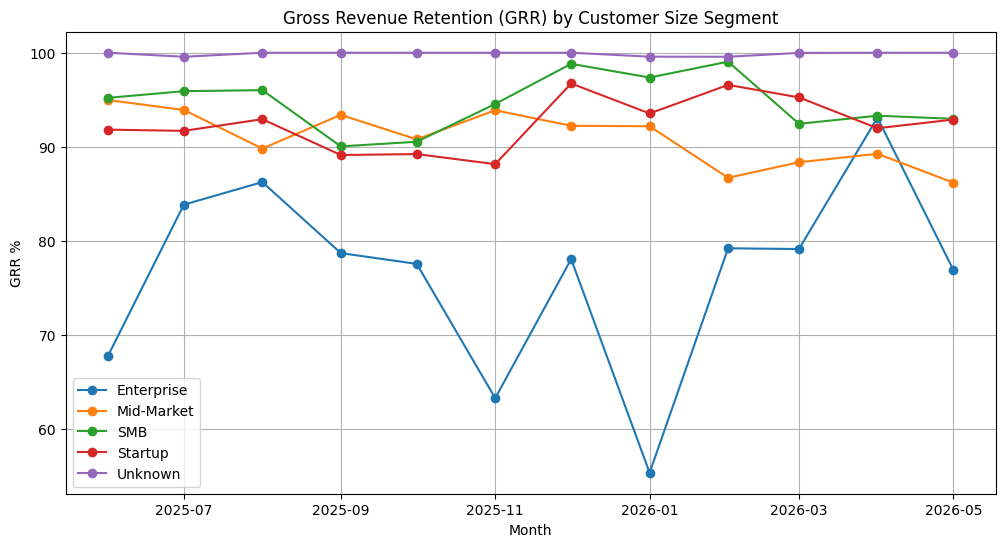

In [4]:
pivot = df.pivot_table(
    index = "month_start_date",
    columns = "size_grouped",
    values = "grr_pct"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker="o", label=col)
    
plt.title("Gross Revenue Retention (GRR) by Customer Size Segment")
plt.xlabel("Month")
plt.ylabel("GRR %")
plt.legend()
plt.grid(True)
plt.show()

# GRR Drop in Jan 2026 – Impact of Void Invoices (Enterprise Segment)

## Key Observation

In January 2026, there is a significant drop in GRR for the Enterprise segment.

This is an outlier compared to surrounding months where Enterprise GRR remains relatively stable.

## Root Cause

The drop is explained by data-level revenue adjustments due to voided invoices:

Two invoices for Enterprise customers were marked as voided.
The impacted accounts are: `sub_e2260b8a7006da97` and `sub_35b8d570e045e47a`
Included in baseline cohort revenue (M-12 comparison base)
Excluded from retained revenue in Jan 2026

# Cohort Size Trend (Sanity Check)

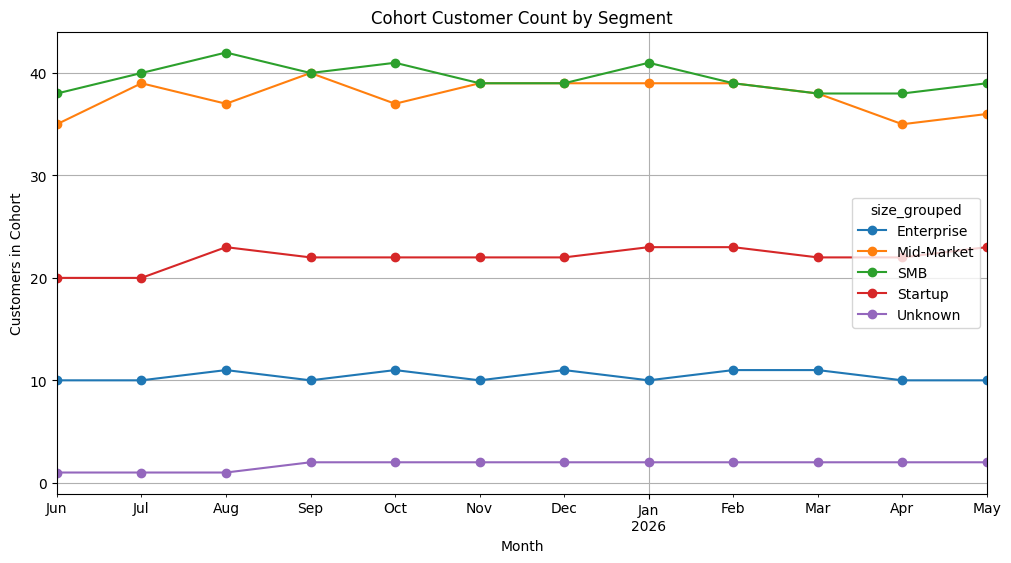

In [5]:
pivot_cohort = df.pivot_table(
    index="month_start_date",
    columns="size_grouped",
    values="cohort_customer_count"
)

pivot_cohort.plot(
    figsize=(12,6),
    marker="o",
    title="Cohort Customer Count by Segment"
)

plt.xlabel("Month")
plt.ylabel("Customers in Cohort")
plt.grid(True)
plt.show()